In [1]:
pip install requests pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("task2_cleaned_weather_data.xlsx")

numeric_cols = [
    "temperature_2m_max", "temperature_2m_min", "temperature_2m_mean",
    "precipitation_sum", "windspeed_10m_max", "relative_humidity_2m_mean"
]

print(f"Loaded Task 2 data: {df.shape[0]} rows × {df.shape[1]} columns")

Loaded Task 2 data: 1830 rows × 13 columns


In [2]:
df[numeric_cols].describe().round(2)

,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,windspeed_10m_max,relative_humidity_2m_mean
count,1830.00,1830.00,1830.00,1830.00,1830.00,1830.00
mean,32.40,23.69,27.45,3.17,14.77,69.80
std,3.45,2.08,2.46,5.60,3.60,22.58
min,24.90,16.80,22.80,0.00,5.50,7.00
25%,29.80,22.50,25.60,0.00,12.20,61.00
50%,32.00,23.50,27.20,0.90,14.30,80.00
75%,34.50,24.70,28.40,3.60,17.00,85.00
max,43.30,31.40,36.20,71.30,28.80,98.00


In [3]:
# City-level averages
df.groupby("city")[numeric_cols].mean().round(2)

,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,windspeed_10m_max,relative_humidity_2m_mean
city,,,,,,
Accra,30.53,24.31,26.96,2.50,17.64,81.96
Bawku,34.87,23.82,28.84,2.37,15.74,49.31
Kumasi,31.91,22.84,26.47,4.00,12.58,76.34
Takoradi,30.57,23.52,26.39,4.18,12.71,84.86
Tamale,34.09,23.94,28.58,2.78,15.19,56.51


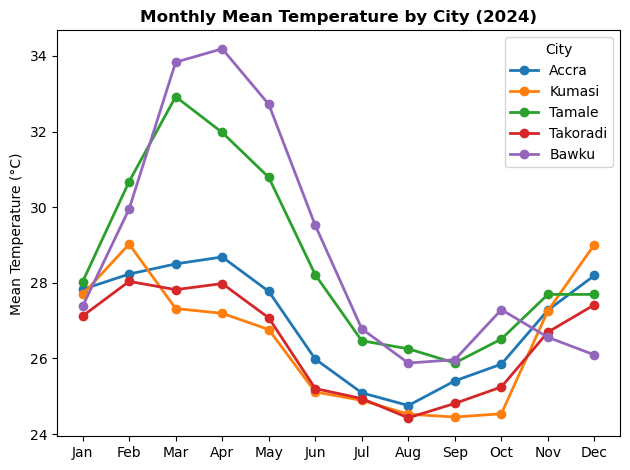

In [4]:
monthly_temp = df.groupby(["month", "city"])["temperature_2m_mean"].mean().reset_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots()
for city in df["city"].unique():
    data = monthly_temp[monthly_temp["city"] == city]
    ax.plot(data["month"], data["temperature_2m_mean"], marker='o', linewidth=2, label=city)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title("Monthly Mean Temperature by City (2024)", fontweight='bold')
ax.set_ylabel("Mean Temperature (°C)")
ax.legend(title="City")
plt.tight_layout()
plt.savefig("chart1_temperature_trends.png", dpi=150, bbox_inches='tight')
plt.show()

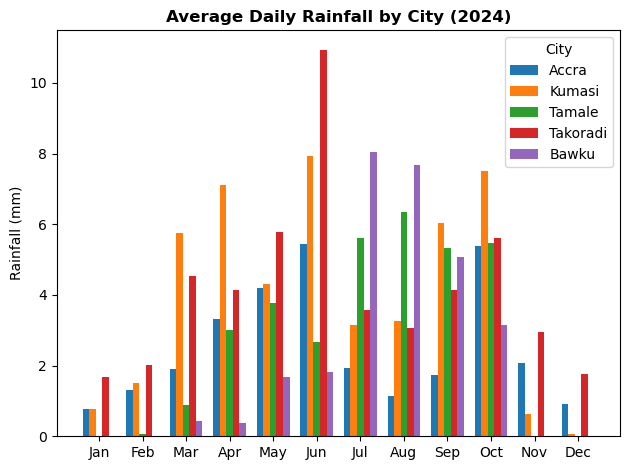

In [5]:
monthly_rain = df.groupby(["month", "city"])["precipitation_sum"].mean().reset_index()
x = np.arange(12)
bar_width = 0.15
cities_list = df["city"].unique()

fig, ax = plt.subplots()
for i, city in enumerate(cities_list):
    data = monthly_rain[monthly_rain["city"] == city]
    ax.bar(x + i * bar_width, data["precipitation_sum"], width=bar_width, label=city)

ax.set_xticks(x + bar_width * 2)
ax.set_xticklabels(month_labels)
ax.set_title("Average Daily Rainfall by City (2024)", fontweight='bold')
ax.set_ylabel("Rainfall (mm)")
ax.legend(title="City")
plt.tight_layout()
plt.savefig("chart2_rainfall_patterns.png", dpi=150, bbox_inches='tight')
plt.show()

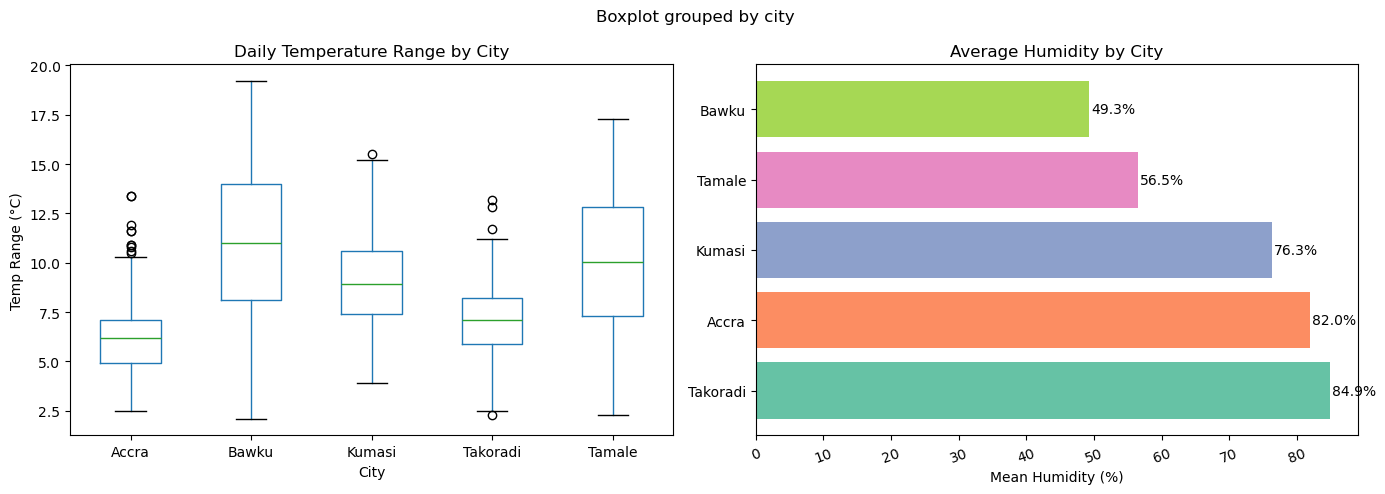

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column="temp_range", by="city", ax=axes[0], grid=False)
axes[0].set_title("Daily Temperature Range by City")
axes[0].set_xlabel("City")
axes[0].set_ylabel("Temp Range (°C)")
plt.xticks(rotation=20)

humidity = df.groupby("city")["relative_humidity_2m_mean"].mean().sort_values(ascending=False)
axes[1].barh(humidity.index, humidity.values, color=sns.color_palette("Set2", 5))
axes[1].set_xlabel("Mean Humidity (%)")
axes[1].set_title("Average Humidity by City")
for i, v in enumerate(humidity.values):
    axes[1].text(v + 0.3, i, f"{v:.1f}%", va='center')

plt.tight_layout()
plt.savefig("chart3_temp_range_humidity.png", dpi=150, bbox_inches='tight')
plt.show()

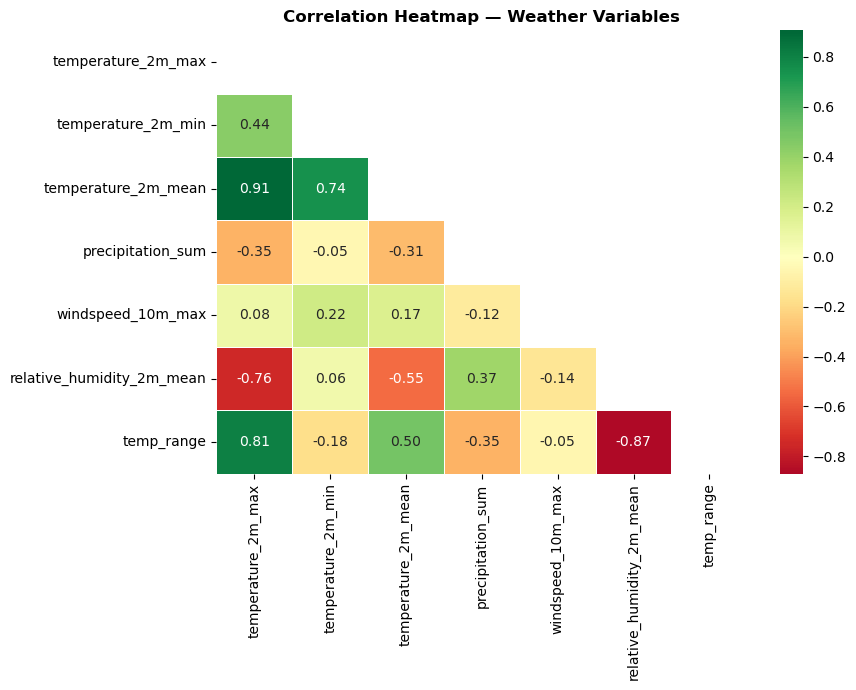

In [7]:
corr_cols = numeric_cols + ["temp_range"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", mask=mask,
            cmap="RdYlGn", center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap — Weather Variables", fontweight='bold')
plt.tight_layout()
plt.savefig("chart4_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()